In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
sys.path.append('/home/mvargas/code/Huawei/survan')

from deep_lambda_cox import DeepLambdaSA
from lambda_cox import LambdaSA
from baseline_cox import SA

from utils import concordance_index, unroll, get_single_task_dataset, kaplan_meier, pad_to, get_single_target_and_mask, score
import yaml
import jax
import jax.numpy as jnp
import numpy as np
import haiku as hk
import matplotlib.pyplot as plt

In [2]:
config_path = '../configs/config_kkbox.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [3]:
task_id = 'kkbox'
save_fig = False

In [ ]:
%%time
num_exps = 5
sizes = [.2]

ibs_is = np.zeros((num_exps, len(sizes)))
ibs_lm = np.zeros((num_exps, len(sizes)))

ci_is = np.zeros((num_exps, len(sizes)))
ci_lm = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_is[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_is[fold, i] = concordance_index(scores, ts, cs)

        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        ms = test_gen.mask
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_lm[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.

In [ ]:
%%time

num_exps = 5
sizes = [.2]
size = sizes[0]

bs_0 = np.zeros((num_exps, len(sizes)))
bs_1 = np.zeros((num_exps, len(sizes)))

ci_0 = np.zeros((num_exps, len(sizes)))
ci_1 = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        print(".", end="")
        
        # Landmarking.
        config['lambda_'] = .9
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_1[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)

        scores = model.scores(seqs, q=0.0)
        ci_1[fold, i] = concordance_index(scores, ts, cs)

        # TCSR.
        config['lambda_'] = 0.0
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_0[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_0[fold, i] = concordance_index(scores, ts, cs)
        
    print()

In [ ]:
# save_fig = True
save_fig = False

In [ ]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
bs_is = ibs_is.reshape(-1)
bs_lm = ibs_lm.reshape(-1)
bs_a9 = bs_1.reshape(-1)
bs_a0 = bs_0.reshape(-1)
boxplot = ax.boxplot([bs_is, bs_lm, bs_a0, bs_a9], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['SA Init State', 'SA Landmarking', r'DeepTCSA($\lambda$)=0.0', r'DeepTCSA($\lambda$)=0.9'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Last-fm")
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/lastfm/Int_brier_score_task_transformer_static.pdf", format="pdf")

plt.show()


In [ ]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
ci_is = ci_is.reshape(-1)
ci_lm = ci_lm.reshape(-1)
ci_a9 = ci_1.reshape(-1)
ci_a0 = ci_0.reshape(-1)
boxplot = ax.boxplot([ci_is, ci_lm, ci_a0, ci_a9], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['SA Init State', 'SA Landmarking', r'DeepTCSA($\lambda$)=0.0', r'DeepTCSA($\lambda$)=0.9'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Concordance Index")
ax.set_title("Concordance Index Last-fm")
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/lastfm/Concordance_idx_task_transformer_static.pdf", format="pdf")

plt.show()


In [17]:
config_path = '../configs/config_kkbox.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

config['landmark'] = True
config['num_epochs'] = 100
config['lambda_'] = 0.0
model = SA(config, seed=1)

In [18]:
model.data['seqs'].shape

(136890, 45, 7)

In [19]:
train_gen, test_gen = model.get_train_test(test_size=.999)

In [20]:
train_gen.mask.shape

(137, 45, 45)

In [ ]:
loss = model.train(train_gen, test_gen)

 27%|████████████████████████████████████████████████████                                                                                                                                             | 27/100 [07:33<20:00, 16.44s/it]

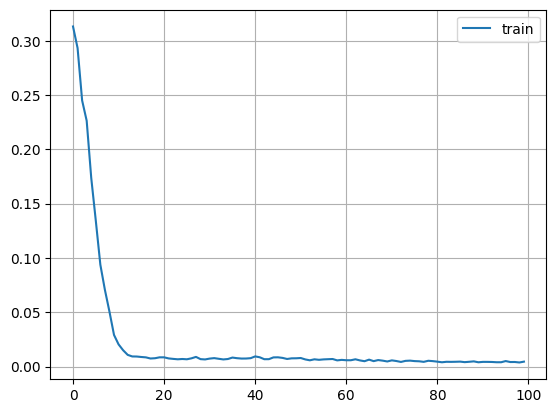

In [23]:
plt.plot(loss[0], label='train')
# plt.plot(loss[1], label='test')
plt.legend()
plt.grid()

In [24]:
model.data['seqs'].shape

(136890, 45, 7)

In [25]:
# plt.plot(tr_loss, label='train')
# plt.plot(te_loss, label='test')
# plt.legend()
# plt.grid()

In [26]:
seqs = train_gen.X
ts = train_gen.ts
cs = train_gen.cs
y = train_gen.y

scores = model.scores(seqs, q=0.0)
concordance_index(scores, ts, cs)

0.49737030839110685

In [33]:
seqs_t = test_gen.X
ts_t = test_gen.ts
cs_t = test_gen.cs
y_t = test_gen.y

scores = model.scores(seqs_t, q=0.0)
concordance_index(scores, ts_t, cs_t)

KeyboardInterrupt: 

In [2]:
from utils import get_churn_kkbox

In [3]:
data_path = '/Users/mariana/Documents/projects/Huawei/SurvanData/kkbox-churn-prediction-challenge/kkbox/chunk'

seqs, ts, cs = get_churn_kkbox(data_path)


> /Users/mariana/Documents/projects/Huawei/survan/utils.py(120)get_churn_kkbox()
    119     # Center and scale
--> 120     scaler = StandardScaler()
    121     cols = ['num_25', 'num_50',	'num_75', 'num_985',



ipdb>  len(df_logs_orig)


555433


ipdb>  n


> /Users/mariana/Documents/projects/Huawei/survan/utils.py(121)get_churn_kkbox()
    120     scaler = StandardScaler()
--> 121     cols = ['num_25', 'num_50',	'num_75', 'num_985',
    122             'num_100', 'num_unq', 'log_minutes']



...

ipdb>  logs1 = df_logs.groupby('msno')
ipdb>  len(logs1)


13455


ipdb>  len(df_logs_orig.groupby('msno'))


136890


ipdb>  exit


In [5]:
seqs.shape

(13455, 45, 7)